<a href="https://colab.research.google.com/github/krlpopiel/SI_lab/blob/develop/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [16]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

In [17]:
def scale(image,label):
  image = tf.cast(image,tf.float32)
  image /= 255.
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [18]:
BUFFER_SIZE = 1000

shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [19]:
BATCH_SIZE = 100

train_data = train_data.batch(BATCH_SIZE)

validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))

print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [20]:
input_size = 784
output_size = 10

hidden_layer_size = 50

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
NUM_EPOCHS = 30
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose = 1
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8827 - loss: 0.4084 - val_accuracy: 0.9372 - val_loss: 0.2152
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9481 - loss: 0.1788 - val_accuracy: 0.9485 - val_loss: 0.1739
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9604 - loss: 0.1337 - val_accuracy: 0.9548 - val_loss: 0.1430
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9681 - loss: 0.1084 - val_accuracy: 0.9615 - val_loss: 0.1258
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9735 - loss: 0.0898 - val_accuracy: 0.9640 - val_loss: 0.1181
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9771 - loss: 0.0769 - val_accuracy: 0.9670 - val_loss: 0.1115
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9803 - loss: 0.0662 - val_accuracy: 0.9645 - val_loss: 0.1098
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9826 - loss: 0.0580 - val_accuracy

In [22]:
test_loss, test_accurancy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accurancy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9710 - loss: 0.0983
Test loss: 0.10. Test accuracy: 97.10%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


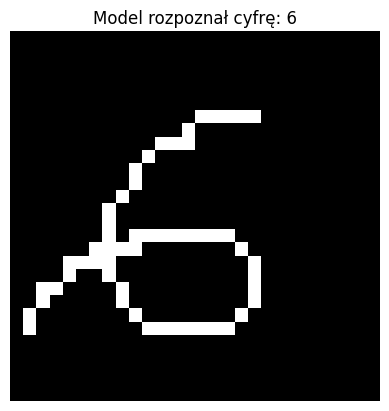

In [26]:
#1. Podanie ścieżki do obrazka
image_path = '/content/szesc.png'

try:
    # 2. Wczytanie obrazka w skali szarości (cv2.IMREAD_GRAYSCALE)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
         print(f"Nie znaleziono pliku: {image_path}. Upewnij się, że został wgrany do Colab.")
    else:
        # 3. Zmiana rozmiaru do 28x28 pikseli
        img_resized = cv2.resize(img, (28, 28))

        # 4. Odwrócenie kolorów (MNIST to białe cyfry na czarnym tle)
        # Jeśli Twój obrazek to już biała cyfra na czarnym tle, zakomentuj poniższą linię:
        img_inverted = cv2.bitwise_not(img_resized)

        # 5. Normalizacja wartości z zakresu 0-255 do 0-1 [cite: 83, 89]
        img_normalized = img_inverted / 255.0

        # 6. Dostosowanie kształtu do wymagań modelu
        # Model oczekuje formatu: (liczba_próbek, wymiar_x, wymiar_y, kanały_kolorów)
        img_reshaped = np.reshape(img_normalized, (1, 28, 28, 1))

        # 7. Wykonanie predykcji [cite: 172]
        prediction = model.predict(img_reshaped)

        # prediction to tablica prawdopodobieństw dla klas od 0 do 9[cite: 41].
        # Wybieramy indeks z najwyższym prawdopodobieństwem:
        predicted_digit = np.argmax(prediction)

        # 8. Wizualizacja obrazka i wyniku predykcji
        plt.imshow(img_inverted, cmap='gray')
        plt.title(f"Model rozpoznał cyfrę: {predicted_digit}")
        plt.axis('off')
        plt.show()

except Exception as e:
    print(f"Wystąpił błąd: {e}")